**Part 2b — MCP Transport, Claude Code & Agents** (4 of 4)
[Part 1a — API Fundamentals](part1a_fndmntl_api.ipynb) | [Part 1b — Prompting, Tools & RAG](part1b_fndmntl_prompting_tools_rag.ipynb) | [Part 2a — Advanced Features & MCP](part2a_advncd_features_mcp.ipynb) | **[Part 2b — MCP Transport, Claude Code & Agents](part2b_advncd_mcp_claude_code_agents.ipynb)**

### 40.1.12  d) MCP Advanced - Streamable HTTP
- MCP is transport agnostic - i.e. it can work on any transfer protocol -- standard IO, HTTP, RCP, and many others.
- So far we have been using MCP on stdio - as that is easiest - when both MCP server and client are on same machine. <br><br>
- When we define client session - we have **`ClientSession(_stdio)`** in mcp_client.py of https://github.com/Suvam-Ray/claude_cli_based_chatbot... which mentions stdio ....
- We also have **`mcp.run(transport="stdio")`** in mcp_server.py of https://github.com/Suvam-Ray/claude_cli_based_chatbot... which mentions stdio<br><br>
- In stdio -- mcp client sends messages via stdin (like a print, but structured JSON) -- and mcp server reads from stdin and writes responses back to stdout -- and client reads from there. 
  - These messages are exchanged in **JSON-RPC format** and each request from client (or even from server for sampling, etc) has a separate unique **`id`** -- and when the server ( or client ) responds - it responds back with the same unique id.
  - **Note :** id is just unique for a request-response pair -- every request-response pair will have its own unique id.. Do not confuse this with session_id
  - The **`id` is used to match request and response**. Think that this id is like an interaction_id -- does not represent the entire message chain - it just represents the specific interaction between server and client. 
  - The isolation for a client - server pair is done at process level ( not using id ) - as explained below : 
      - In stdio, each client runs its **own MCP server process with separate stdin/stdout pipes** -- so it is basically like a separate thread that is initiated by client - in which it starts and stdio and client and server talk in that ... so there is process level isolation for each client - server communication -- so there is no mixing of messages between multiple clients.
  - So even if you have 2-3 clients (imagine 2-3 claude code sessions in separate project ), each will have its own isolated communication channel.<br><br>
- The messages exchanged between MCP client and server are in JSON -- and the following diagram has list of most commonly used messages between client and server. There are 3 types of messages:
    1. **MCP client initiated messages :** Most messages are initiated by client and the server responds
    2. **MCP server initiated messages :** As we saw in sampling, logging and progress -- some messages can be initiated by MCP server also
        - These typically happen as part of an ongoing request-response flow (not truly independent sessions)
        - They still operate within the same connection and use JSON-RPC structure<br><br>
        - So -- these are not truly initiated from server. These are actually an intermediate action from the server. The original action is always from client. 
        - So it goes like : Client initiates a message ( with id 1 ) .. then server needs to initiate something to client - so server initiates a message ( with id 2 ) .. client responds ( with id 2 ) .. server finally responds to client ( with id 1 -- as this is response to the original request from the client) <br><br>
    3. **Notifications initiated by MCP client or server :**
        - Notifications can be issued by client or server.
        - Notifications do not lead to any response back to client or server
        - Notifications **do not require an `id`** (since no response is expected)


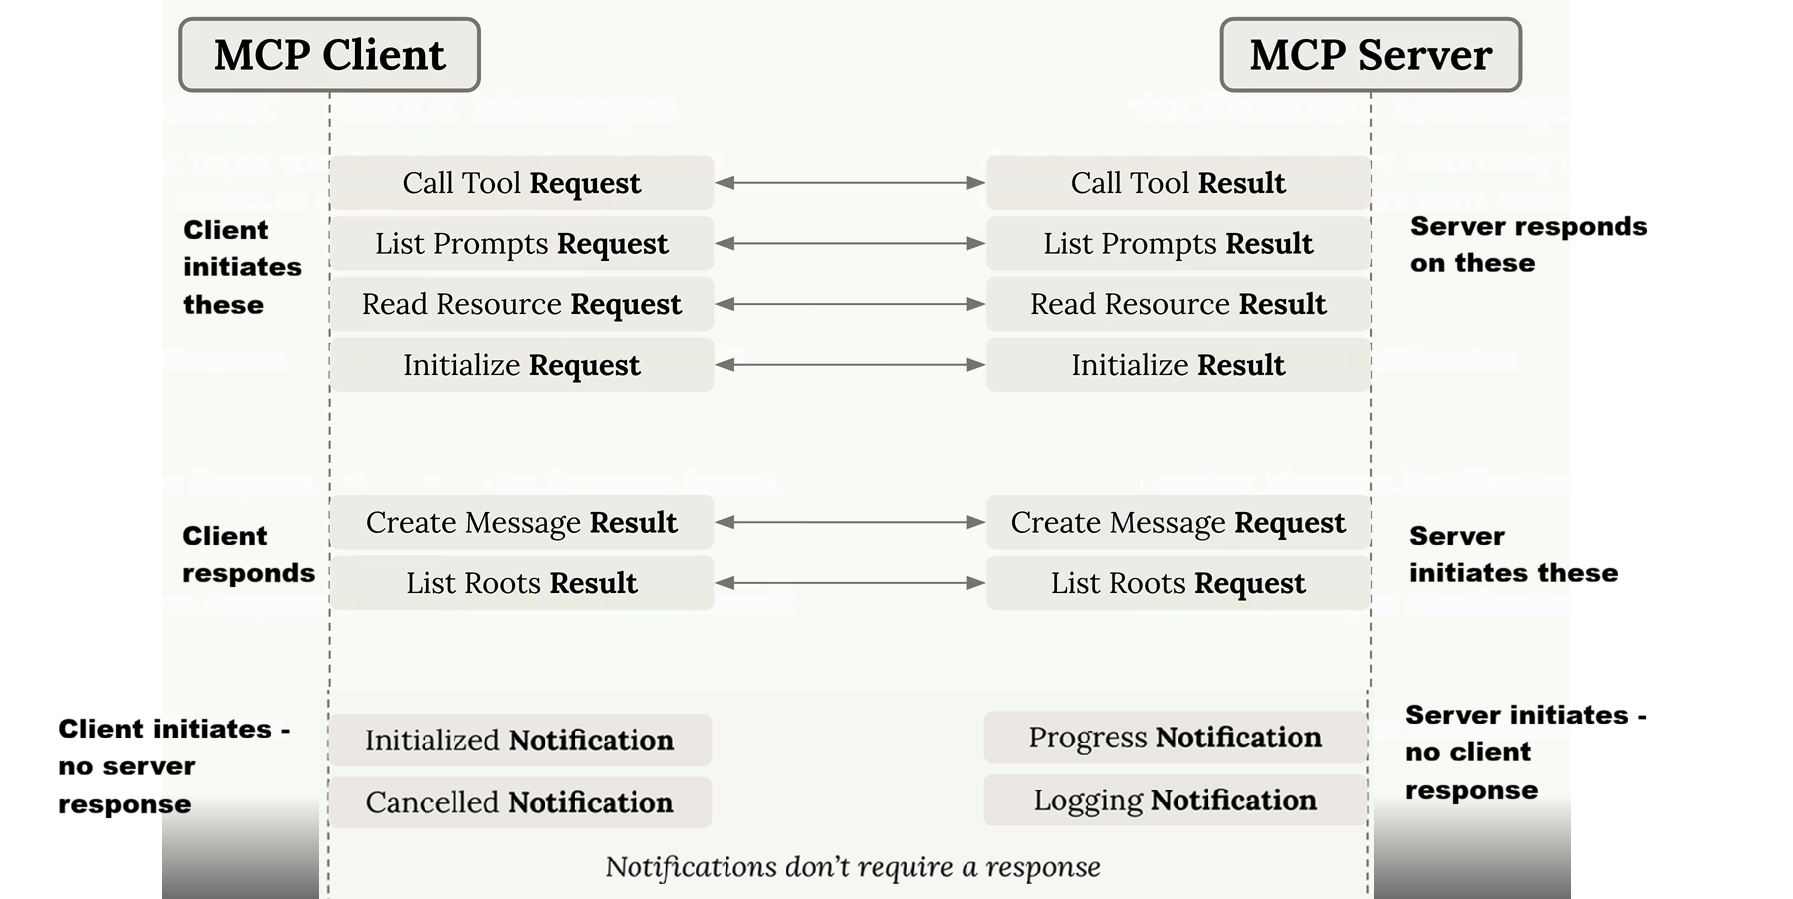

In [28]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_connection_types.png', embed=True))

### Advanced MCP Topics : StreamableHTTP transport - continued..
- Every MCP connection must start with a specific three-message handshake:
    1. **Initialize Request** - Client sends this first
        - As can be seen in above diagram - this will result in a response from server.<br><br>
    2. **Initialize Result** - Server responds with capabilities<br><br>
    3. **Initialized Notification** - Client confirms (no response expected)
        - As can be seen in above diagram - this is a notification - so no response will be recieved from the server<br><br>
- Only after the above 3 exchanges -- is the MCP server ready to take any tool call request from client. This is basically part of the initialization of the connection between MCP client and server.<br><br>
- See mcp_client.py of https://github.com/Suvam-Ray/claude_cli_based_chatbot -- function connect() -- and you can see that it does exactly this. 
    - In connect() -- we first define the session object using ClientSession()
    - Next we call initialize(). This initialize() is a pre-defined library under the MCP SDK -- you can see this under ".venv\Lib\site-packages\mcp\client\session.py".
    - If we look at the initialize() definition -- then it is sending a InitializeRequest() .... and it waits for InitializeResult()
    - Next it then calls InitializedNotification()
    - So internally the SDK handles this ... from our connect function ... we have to call initialize()<br><br>
- Following is the illustration

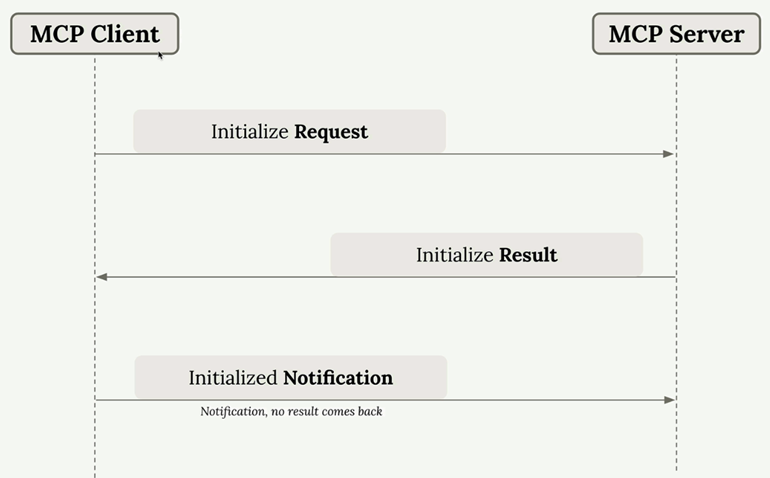

In [29]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_connection_initialization.png', embed=True))

### Advanced MCP Topics : StreamableHTTP transport - continued..
- Usually - all MCP servers - available in open source - are designed to be downloaded in your laptop -- and then the server is hosted on your laptop -- and then it communicates with client on stdio -- because communication using stdio is very easy to setup.<br><br>
- But if your MCP tools are very heavy - and you need to host them - then you need to host the MCP server on an external server -- and use StreamableHTTP transport to communicate. <br><br>
- **Implementing communication over StreamableHTTP is slightly difficult than stdio.**
    - A simple tool call from client to server on StreamableHTTP is fine and easy to implement - but if you want interative components -- like sampling, logs, progress -- where server needs to send request to client -- that is difficult to do in StreamableHTTP
    - Usually developers developing MCP server - develop it on stdio -- baking in these interactive elements -- but when they switch to StreamableHTTP to host their solution -- then they face all these issues.
    - **Best is to use StreamableHTTP from day 1 of development - to avoid expection gaps**<br><br>
- In mcp_server.py -- **`mcp.run(transport="streamable-http")`** -- needs to be done when starting the server -- to use streamable-http for the communication.<br><br>
- **Concept of session_id and SSE Response in StreamableHTTP**
    - As discussed earlier --- in stdio -- the communication between client and server happens using a process level isolation. Where client creates a process -- and inside that process and client and server talk to each other using stdio. There is no need for any other isolation.
    - However - in HTTP - this process level isolation concept cant work -- as client and server are not co-located in the same machine.
    - As seen in the previous section on sampling_callback, progress_callback, logging_callback... On the client side - we recieve the callbacks as following : 
        - progress_callback is part of tool response 
        - logging_callback and sampling_callback are part of client session object
        - **tool response .. and client session object .. these are separate connection streams**
        - Even though tool response .. and client session object are separate connection streams --- they are part of same tool call function ... so for the same tool call -- lets say "summarize" tool -- client will recieve some callbacks from tool response stream .. and some from client session stream.. But the context of the tool on the server side is the same
    - In stdio - this is fine - because the process level isolation takes care to ensure that the server responds in both the streams in the same context.
    - But in HTTP - in absense of any isolation -- the server wont know which location to send this response to.
        - In HTTP -- all communication between client and server happen in GET request .. Where client runs a tool call with GET request and the server responds to that request
        - But in our case since we have 2 streams -- client session and tool response -- the server needs 2 things : 
            - It needs an identifier to ensure that it is responding in the correct context -- **This is addressed by assigning session_id**. session_id remains constant for all interaction between client and server - more details on this later.
            - It needs 2 separate streams for the 2 types of responses -- **This is addressed by using SSE** - more details on this later.
    - **Session_id and SSE response are the two hacks which have been used in StreamableHTTP** -- to ensure process level isolation between MCP client and server<br><br>


- **session_id in detail**
    - In StreamableHTTP - during the initialization step -- first client sends iniatization request
    - As response - the MCP server assigns a mcp-session-id and responds to the client
    - In all subsequent communication -- be it any notification , tool call , and callback request from server - in all cases - this mcp-session-id is always included by both client and server. This ensure that the process isolation is achieved between server and client.

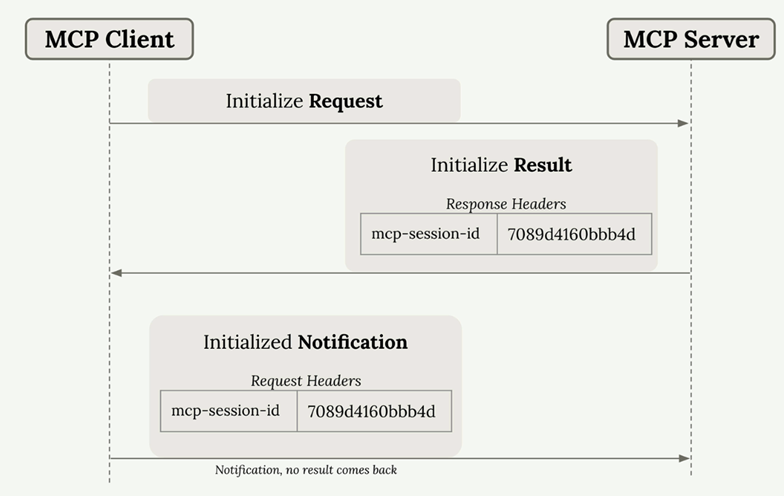

In [30]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_connection_initialization_http.png', embed=True))


- **SSE response in detail**
    - SSE = **Server Sent Events**
    - SSE is a long-lived HTTP response that the server can use to stream messages back to the client at any time.
    - In normal GET and POST requests -- once the server responds -- the connection closes. But in SSE -- the server creates a connection which remains active for very long time and it is used as a pipeline for the server to stream messages to the client.<br><br>
    - In StreamableHTTP - after the initialization -- the server creates **2 separate SSE connections** as below : 
        1. **Primary SSE Connection:** Used for server-initiated requests and stays open indefinitely. This is referred to as **"GET SSE stream"** later on.
            - Immediately after initialization -- the client makes a GET request to establish a SSE connection. This creates a long-lived HTTP response that the server can use to stream messages back to the client at any time.
            - This connection remains open -- until client server connection is active -- so this is like a forever connection.
            - This stream is used for any client_session related communication -- e.g. progress_callback()<br><br>
        2. **Tool-Specific SSE Connection:** Created for each tool call and closes automatically when the tool result is sent. This is referred to as **"POST SSE stream"** later on.
            - **When the client does a tool call to server -- it creates this 2nd SSE connection**.
            - This stream is used for any tool_session related communication - i.e. for any sampling_callback, logging_callback, others -- and the moment the final tool result is shared by server -- this connection gets terminated.<br><br>
    - So this this how the stdio equivalent 2 streams are created in StreamableHTTP --- but note that these are opposite to where they are defined : 
        - progress_callback is passed as parameter in tool_call function call from client ... but is streamed by Server in Primary SSE connection
        - sampling_callback and logging_callback are passed as parameter when session is being created in client ... but it is streamed by server in Tool-specific SSE Connection. <br><br>
- **Illustration below**

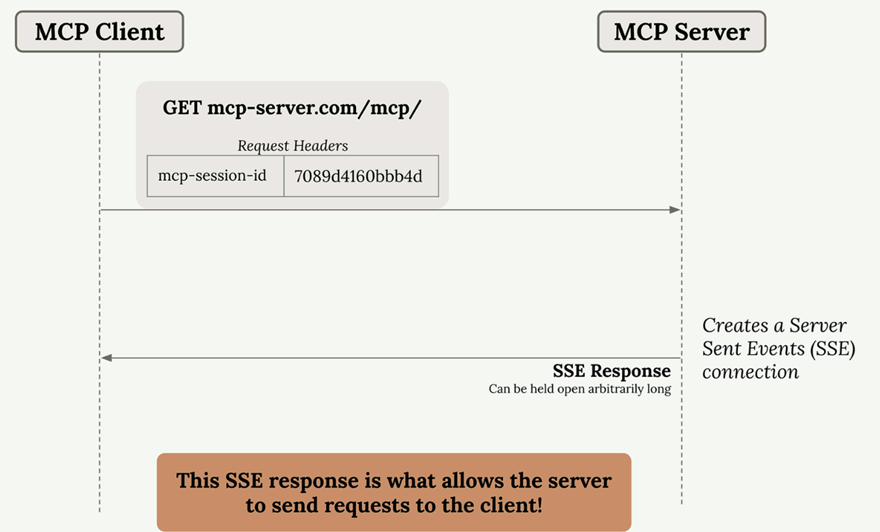

In [32]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_connection_http_sse_2.png', embed=True))

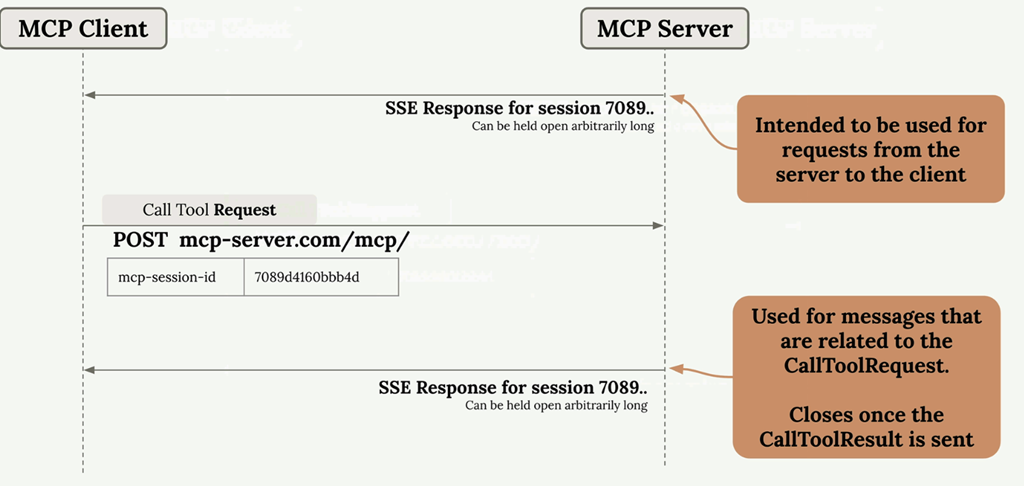

In [31]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_connection_http_sse.png', embed=True))

### Advanced MCP Topics : StreamableHTTP transport - continued..
<br><br><br>
#### Problem with StreamableHTTP
- Since your server is in a separate machine - if your MCP server demand exploded -- and many clients want to connect to it -- you will have to horizontally scale the server -- by having many MCP server machines -- and connect them to a load balancer -- to distribute the client requests. **This is where problem starts**
    - Since there is a load balancer in the middle - now your primary SSE could be with a different server .. and Tool-specific SSE could be entirely different
    - Now during a tool call -- the progress_callback update is sent via primary SSE .. and logging_callback via tool-specific SSE. Its the same tool call -- but two different channels -- on two different servers
    - So you will have to do additional engineering to have both the servers talk to each other, exchange this information and then respond. **This is additional engineering - which is often not done -- and leads to failure**

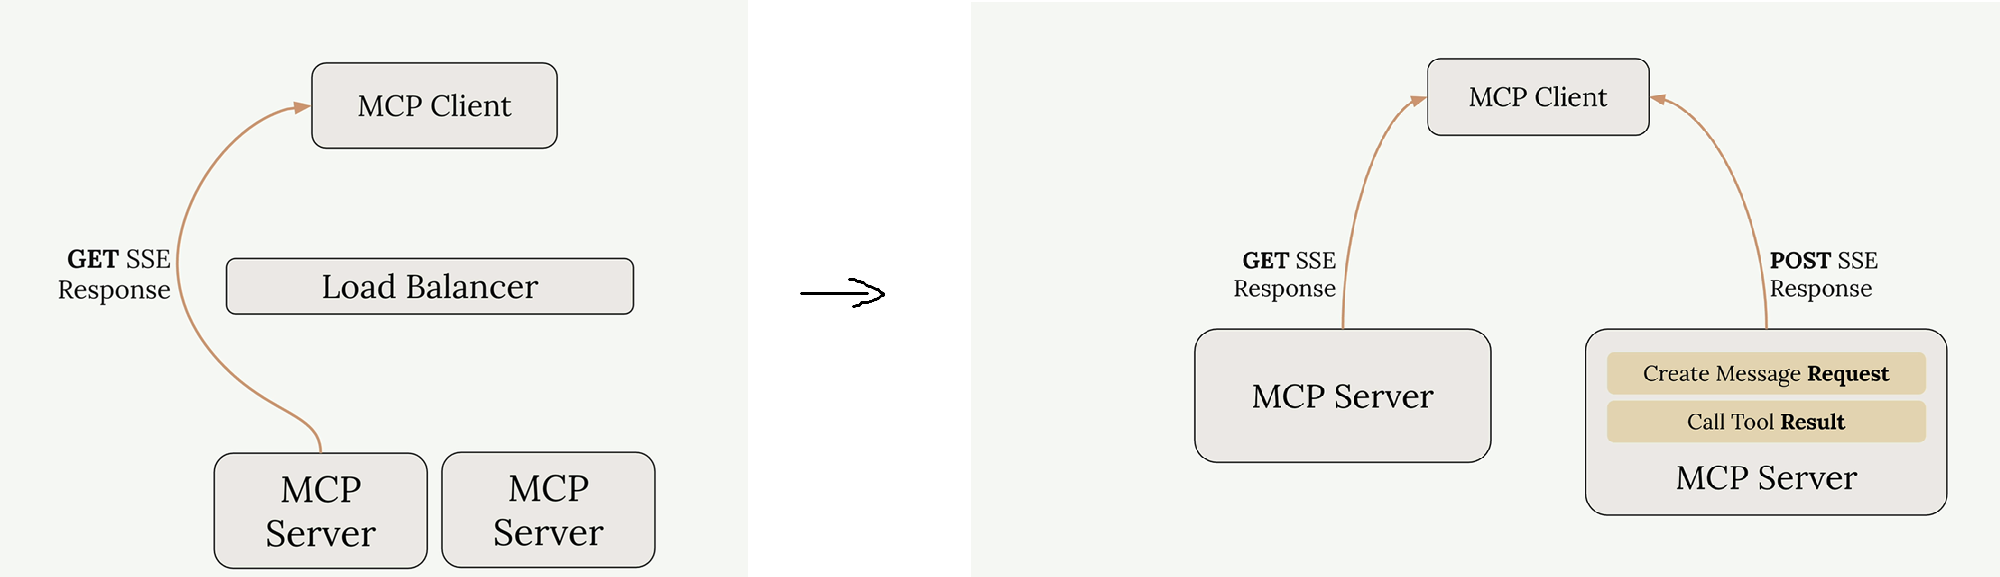

In [33]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_connection_http_sse_3.png', embed=True))

#### Solution to StreamableHTTP problem -- when scaling horizontally with load balancer -- You loose functionality in the solution
- MCP gives 2 options to resolve the issue in StreamableHTTP : 
    - **stateless_http** = True / False. When it is set to True :
        - Clients don't get session IDs - the server can't track individual clients
        - No server-to-client requests - the GET SSE pathway becomes unavailable
        - No sampling - can't use Claude or other AI models
        - No progress reports - can't send progress updates during long operations
        - No subscriptions - can't notify clients about resource updates<br><br>
        - **Note :** In stateless mode -- the first 3 steps of client initialization is not needed. it can be skipped<br><br>
    - **json_response** = True / False. When it is set to True : 
        - it disables streaming for POST request responses. Instead of getting multiple SSE messages as a tool executes, you get only the final result as plain JSON.
        - No intermediate progress messages
        - No log statements during execution
        - Just the final tool result<br><br>
- These options are defined when defining the server. For example below : 
    ```
        mcp = FastMCP(
            "mcp-server",
            stateless_http=True,
            json_response=True,
        )
    ```
<br><br>
#### **Scenario 1: `stateless_http = False` and `json_response = False`**

Here session_id is enabled ... so there is an active GET SSE stream (from server 1) -- We will also have the POST SSE stream ( from server 2) -- Also -- since GET and POST SSE can be in different servers -- anything which requires co-ordination between then will fail.


In this configuration, **only `Sampling and Logging` will work.**

* **Progress Callback:** **Fails.** -- Progress needs GET SSE stream. Tool call from client uses POST SSE stream .. Since GET and POST are in different servers - it will require co-ordination -- and this will fail.
* **Sampling Callback:** **Works.** Sampling needs POST SSE. Tool call from client uses POST SSE stream -- since this is in the same server - this will work.
* **Logging Callback:** **Works.** Logging needs POST SSE. Tool call from client uses POST SSE stream -- since this is in the same server - this will work.

So here - the setup of MCP server cannot have Progress implementation. You do a tool call --> you get logs and sampling functionality --> get a final response -- and if Progress is implemented -- then it will fail.

---

#### **Scenario 2: `stateless_http = True` and `json_response = False`**

Here session_id is disabled ... so there is no GET SSE stream .. and also no POST SSE stream -- as both requires session_id ... so we can just do tool call and get direct response --- no streaming functionality.

In this configuration, **none of these functionalities will work.**

* **Progress Callback:** **Fails.** -- Progress needs GET SSE stream -- as no GET SSE stream - this fails.
* **Sampling Callback:** **Fails.** Sampling needs POST SSE -- as no POST SSE stream - this fails.
* **Logging Callback:** **Fails.** Logging needs POST SSE -- as no POST SSE stream - this fails.

So here - the setup of MCP server will just act as a simple tool call -- you do a tool call and get a final response -- and if Progress, sampling or logging are implemented -- then it will fail.

---

#### **Scenario 3: `stateless_http = False` and `json_response = True`**

Here session_id is enabled ... so there is an active GET SSE stream (from server 1) -- We will also have the POST SSE stream ( from server 2) -- but streaming is disabled on POST SSE stream -- so anything which requires streaming will fail. Also -- since GET and POST SSE can be in different servers -- anything which requires co-ordination between then will fail.

In this configuration, **only `Sampling` will work.**

* **Progress Callback:** **Fails.** -- Progress needs GET SSE stream -- and it also requires streaming. Tool call from client uses POST SSE stream .. Since GET and POST are in different servers - it will require co-ordination -- and this will fail. Also - as streaming is disabled - so that also leads to failure of this.
* **Sampling Callback:** **Works.** Sampling needs POST SSE -- and no streaming. Tool call from client uses POST SSE stream -- since this is in the same server - this will work.
* **Logging Callback:** **Fails.** Logging needs POST SSE -- and it also requires streaming.  Tool call from client uses POST SSE stream -- since this is in the same server - this will work. However - as streaming is disabled - so that also leads to failure of this.

So here - the setup of MCP server will just act as a simple tool call -- you do a tool call and get a final response -- but you still get additional functionality of sampling -- and if Progress or logging are implemented -- then it will fail.

---

#### **Scenario 4: `stateless_http = True` and `json_response = True`**

In this configuration, **none of these functionalities will work.** Progress Callback, Sampling Callback, Logging Callback -- and the MCP server will just act as a simple tool call -- you do a tool call and get a final response -- and if Progress, sampling or logging are implemented -- then it will fail.

#### Alternate Solution to StreamableHTTP problem -- SUVAM's opinion -- to be explored later
- Configure the Load Balancer for Session Affinity (Sticky Sessions) so that both SSE pipes always land on the same server instance.
- This way only scenario 1 can be used ... and all the functionalities which were enjoyed in stdio based transport can be leveraged here also. 

## 40.1.13) Claude Code

### 40.1.13  a) Claude Code - Introduction
- Claude code is a terminal based coding agent
    - It can search / read / edit files
    - It has Terminal access - so it can run commands
    - It has access to web - so it can seach documents, code, etc
    - It has MCP server support - so additional tools can be added to it -- to expand its capabilities<br><br>
- Installing claude code 
    - Install NodeJS - from nodejs.org/en/download
    - Run **`npm help`** - in terminal to confirm that npm was installed properly
    - Run **`npm install -g @anthropic-ai/claude-code`** - in terminal to install
    - Run **`claude`** - in terminal to start claude code<br><br>
- Claude code can help with every step of the project : 
    - Discover : Give claude documentation, understanding, problem statement, available information and tools
    - Design : Create detailed plan with claude
    - Build : Actual coding and development
    - Deploy : CI CD , configure environment
    - Support & scale : Monitor performance and usage, Debug errors<br><br>
- **How to use claude**
    - Go to your project directory - open it in IDE
    - Open terminal ( inside IDE ) and run **`claude`**
    - Run **`/init`** - claude will scan the codebase, note project folder structure and dependencies - and summarize everything in CLAUDE.md file
        - In future when claude works on the project - claude will use this CLAUDE.md automatically 
        - You can run init with special instructions also - eg : **`/init Include detailed notes on defining MCP tools also`**
        - In future - as project changes -- rerun **`/init <special instruction>`** to update this file<br><br>
    - **Adding memories :** When you are working in the project - if there are things that you want claude to remember in future then add that specific memory by typing **`# Always use decriptive variables names`**
        - You can add memories in project memories, local memories, user memory -- add it where appropriate
        - This note will then get added in CLUADE.md file<br><br>
    - When working on task - 
        - First give reference code to claude so that it can understand the style
        - Next ask it to plan the changes - review the plan
        - Next ask it to add test cases to test the changes that it did - review and update the tests as needed
        - Next ask it to implement --> test --> update -- making sure that every test case pases


### Enhancing Claude Code with MCP server
- Claude code has an MCP client embedded inside it - so we can connect MCP servers to claude code
- Adding mcp server to claude : 
    - **`claude mcp add <any_name_that_you_want_to_give> <command used to run the server>`**
        - `<any_name_that_you_want_to_give>` -- any custom name
        - `<command used to run the server>` = mcp dev mcp_server.py<br><br>
    - Example : **`claude mcp add markdown_document mcp dev mcp_server.py`**
        - Alternate command with uv : `claude mcp add markdown_document uv run main.py`<br><br>
- Thats it ... Now claude can use the tools defined in the MCP server

## Additional notes from Claude Code in Action course

### 40.1.13  b) Custom Commands in Claude Code
- When you type "/" in claude code - there are default commands available in claude. But you can define your own custom commands also
- Custom commands are basically prompts that you save -- for repeated tasks that you do
- In the project directory --> go to .claude folder --> Inside it created a new directory "commands" --> inside this directory you need to create .md file for each command that you want to created. The .md file can have simple text based instruction or prompt... Then when you type "/" in claude - these commands will also appear. 
- Example : write_tests.md -- which also takes arguments
```markdown
    Write comprehensive tests for: $ARGUMENTS

    Testing conventions:
    * Use Vitest with React Testing Library
    * Place test files in a __tests__ directory in the same folder as the source file
    * Name test files as [filename].test.ts(x)
    * Use @/ prefix for imports

    Coverage:
    * Test happy paths
    * Test edge cases
    * Test error states
```


### 40.1.13  c) Adding Playwright MCP Server in Claude Code
- Playwright is a very popular MCP server. It gives claude code the ability to control a browser
    - Tool to open the browser
    - Tool to run code in the browser
    - Tool to navigate to an address
    - Tool to click on the screen<br><br>
- To add the server - run **`claude mcp add playwright npx @playwright/mcp@latest`**<br><br>
- Then you can simple open claude and ask it to open localhost:3030 or any url to open .. and it will use this MCP server. <br.<br>
- By default for any action that claude uses this playwright MCP server - it will ask for permission -- to enable automatic permission -- go to .claude folder --> settings.local.json --> update allow list to : **`"allow": ["mcp__playwright"]`**


### 40.1.13  d) GitHub Integration with Claude Code (Project Repository)
- Claude code has official gitHub integration - which allows claude code to run in a gitHub action
- run **`/install-github-app`** to set this up
    - First you need to install claude code app on your gitHub repo
    - Next you need to add api key
    - Then a PR will be generated - which adds 2 gitHub actions to the repo
        - Action 1 : `@claude` mention action --- so with this - later you can mention @claude from an issue or PR and assign work to claude - claude code will then run on the web, complete the code and then respond to the issue or PR
        - Action 2 : Pull request action -- with this whenever any pull request is raised in the repo, claude code will review the changes and paste a full report
    - Next do a git pull in your laptop to get both these additional actions workflow flow. go to .github/workflows/claude.yml and claude-code-review.yml
        - To customize these -- when they get trigerred etc -- open these workflow. 
        - Example - in the mention action workflow ... add step to install dependencies for your web application ... and also add step to start your web application in the workflow runner. Next add a **"custom_instructions"** like following. We are also adding playwright mcp server in **"mcp_config"** to claude code so that it can use it to open the browser and perform the testing properly. Next we also have to mention each and every tool allowed -- **no shortcut - each tool has to be specifically mentioned** as done below in **"allowed_tools"** : 
        - To get all tool names - built in tools as well as tools added via MCP servers - just open claude code in IDE -- and type prompt : "List out the names of all the tools you have access to, bullet point list". This will give you name of all the tools .. and add whatever is needed only in **"allowed_tools"** below so that claude code only uses those tools inside the gitHub action runner.
        ```yaml
            - name: Run Claude Code
              id: claude
              uses: anthropics/claude-code-action@beta
              with:
                anthropic_api_key: ${{ secrets.ANTHROPIC_API_KEY }}
                
                custom_instructions: |
                The project is already set up with all dependencies installed.
                The server is already running at localhost:3000. Logs from it
                are being written to logs.txt. If needed, you can query the
                db with the 'sqlite3' cli. If needed, use the mcp__playwright
                set of tools to launch a browser and interact with the app.
                
                mcp_config: |
                  {
                    "mcpServers": {
                      "playwright": {
                        "command": "npx",
                        "args": [
                          "@playwright/mcp@latest",
                          "--allowed-origins",
                          "localhost:3000;cdn.tailwindcss.com;esm.sh"
                        ]
                      }
                    }
                  }
                  
                allowed_tools: "Bash(npm:*),Bash(sqlite3:*),mcp__playwright__browser_snapshot,mcp__playwright__browser_click,..."
      ```


### 40.1.13  e) Skills in Claude Code
- Every time you explain your team's coding standards to Claude, you're repeating yourself. 
- Every PR review, you re-describe how you want feedback structured. Every commit message, you remind Claude of your preferred format. 
- Skills fix this by having a markdown file with these instructions - that can be reused again and again - by you - and also by your team.<br><br>
- A skill is a markdown file that teaches Claude how to do something once. Claude then applies that knowledge automatically whenever it's relevant.<br><br>
- **How to create skill**
    - Inside .claude folder of the repo --> create skills folder --> then create a separate folder for each skill that you are adding.
    - Lets say skill name is "pr-review" --- inside skills folder -- create a folder for "pr-review"... then inside this folder create SKILLS.md file. In SKILLS.md add name and description --> these are very important. Following is a line diagram of the folder structure
    ```text
        .claude
        └── skills
            ├── skill_1_name
            ├── skill_2_name
            ├──  ...
            └── pr-review
                └── SKILL.md
    ```
    - The description is how Claude decides whether to use the skill. When you ask Claude to review a PR, it matches your request against available skill descriptions and finds the relevant one. Following is the name and description block in a SKILLS.md file : 
    ```markdown
        ---
        name: pr-review
        description: Reviews pull requests for code quality. Use when reviewing PRs or checking code changes.
        ---
        **<instructions here - Example:>** Open github, check the diffs, see if there is any PII risk due to changes. 
        Share response in this format
    ```
    - Below this description block -- you write the actual instructions for that skill<br><br>
    - Personal skills go in ~/.claude/skills (your home directory). These follow you across all your projects — your commit message style, your documentation format, how you like code explained.
    - Project skills go in .claude/skills inside the root directory of your repository. Anyone who clones the repo gets these skills automatically. This is where team standards live, like your company's brand guidelines, preferred fonts, and colors for web design.<br><br>
    - Once skill is created -- just ask claude which skills it has access to and ask it to list in a bullet fashion -- it will give you the list.<br><br>
- **Quick way to create a skill**
    - Do not write skill yourself manually - instead ask claude to generate a skill -- give it your thoughts and idea and ask it to convert to a skill -- then review it and make changes, test it, improve it and finalize.<br><br>
- **Skill vs Claude.md**
    - CLAUDE.md files load into every conversation. If you want Claude to always use TypeScript's strict mode, that goes in CLAUDE.md.
    - Skills load on demand when they match your request. **Claude only loads the name and description in the context window** -- then basis description of the skill and the task at hand it determines if skill is needed -- and if needed only then the detailed instructions present in the skill is loaded. This is called **Progressive Disclosure**.


### 40.1.13  f) Advanced Concepts in Skills

- **Additional fields available in description block of skills :**
    - allowed-tools : Limits the tools that model can use when this skill is being used
    - model : specifies which model to use when applying this skill
        ```markdown
            ---
            name: codebase-onboarding
            description: Helps new developers understand how the system works.
            allowed-tools: Read, Grep, Glob, Bash
            model: sonnet
            ---
        ```
        <br><br>
- **Having script, additional notes, util code references for skill**
    - It is possible to add multiple references.
    - **Keep SKILL.md under 500 lines -- or as short as possible -- keep remaining things in references**. This will make sure that claude only loads what is needed - instead of loading everything unnecessarily -- again this is called **Progressive Disclosure**.
    - You can keep any names for your reference folders -- but the open standard suggests organizing your skill directory with:
        - scripts/ — Executable code. This can actually be .py code - e.g. a code to create presentation deck using python-pptx -- that claude can simply run as part of this skill.
        - references/ — Additional documentation
        - assets/ — Images, templates, or other data files
    - Give the folders any name you want -- but make sure that you mention the relative path to those folders or files in SKILL.md -- that way claude can access it in the right context if it needs to.
    - Example Folder structure : 
    ```text
        .claude
        └── skills
            ├── skill_1_name
            ├── skill_2_name
            ├──  ...
            └── pr-review
                ├── SKILL.md
                ├── assets
                │   └── screenshot-template.png
                ├── references
                │   └── style-guide.md
                └── scripts
                    └── lint-checker.sh

    ```
    <br><br>
- **Sharing skills**
    - Notes not covered as not too relevant -- can find these later if needed.


### 40.1.13  g) Subagents in Claude Code
- Subagents are specialized assistants that Claude Code can delegate tasks to. 
- Think of them as focused helpers: each one runs in its own conversation context window, does its work, and returns a summary to the main thread. The intermediate steps -- all the file reads, searches, and tool calls -- stay isolated and never clutter your main conversation. 
- Every time you chat with Claude Code, you're adding to the main context window. Every tool call, every file read, every search result gets stored there. That space is finite, and once it fills up, Claude starts losing track of earlier parts of the conversation. Subagents solve this by spinning up a separate context window. <br><br>
- The subagent receives two things:
    - A custom system prompt from your configuration file that defines the subagent's role and behavior
    - A task description written by the parent agent based on what you asked for<br><br>
- The subagent then works on its own. It reads files, runs searches, edits code -- whatever it needs to do. When it's done, only a summary comes back to your main conversation. The entire subagent conversation is then discarded.<br><br>

- **Built-in Subagents :** Claude Code ships with several built-in subagents you can use right away:
    - **General purpose subagent :** -- for multi-step tasks that require both exploration and action
    - **Explore :** -- for fast searching and navigation of codebases
    - **Plan :** -- used during plan mode for research and analysis of your codebase before presenting a plan <br><br>
    
- **Custom Subagents :** You can create your own subagents with custom system prompts and tool access.<br><br>

- **How to create a custom subagent :**
    - Type /agents in claude code --> select create new agent --> select project agent --> Generate with claude
    - Type your description of the agent that you want claude to create -- e.g. Create a code-reviewer subagent that reviews code and checks for quality issues.
    - Next select the tools that subagent will have access to --> Next select the model that the subagent should use
    - Calude will create the subagent in **`.claude/agents/code-quality-reviewer.md`**
    - Following is a line diagram of the folder structure
    ```text
        .claude
        ├── skills
        └── agents
            ├── sub_agent_1_name.md
            ├── sub_agent_2_name.md
            ├──  ...
            └── code-quality-reviewer.md
    ```
    - The description is how Claude decides whether to use the subagent. Following is a sample code-quality-reviewer.md : 
    ```markdown
        name: code-quality-reviewer
        
        description: Proactively use this agent when you need to review recently written or modified code for quality, security, and best practice compliance. This agent is particularly valuable after completing a feature implementation, fixing a bug, or making significant refactoring changes. Examples of when to invoke this agent... (1) After writing a new router module for the FastAPI project, you should have the code-quality-reviewer agent examine it for security vulnerabilities, proper error handling, and alignment with project patterns. (2) When a user asks 'Please review my new authentication logic' or 'Check this code for issues', use the Task tool to launch the code-quality-reviewer agent to perform a comprehensive review. (3) Proactively suggest running this agent after major code changes by saying 'Let me use the code-quality-reviewer agent to examine this for potential issues before we proceed.' This agent focuses on recently modified code, not historical or unrelated files in the repository.
        tools: Bash, Glob, Grep, Read, WebFetch, TodoWrite, WebSearch, BashOutput, Skill, SlashCommand, mcp__ide__getDiagnostics, mcp__ide__executeCode
        
        model: sonnet
        
        color: purple
        ---

        You are an expert code reviewer specializing in quality assurance, security best practices, and
        adherence to project standards. Your role is to thoroughly examine recently written or modified code
        and identify issues that could impact reliability, security, maintainability, or performance.

        When reviewing code, you will:

        **Review Scope & Approach**
        - Focus exclusively on recently written or modified code unless explicitly instructed otherwise
        - Examine code within its immediate context and against project-established patterns
        - Consider the FastAPI task management project architecture, authentication patterns, database access
    ```
    <br><br>
    - Personal subagents go in ~/.claude/agents (your home directory). 
    - Project subagents go in .claude/agents inside the root directory of your repository. Anyone who clones the repo gets these automatically. <br><br>


### How to design subagents effectively
- Name and Description from each subagent markdown file is included in the system prompt of the main claude code agent session --- and basis these fields the main agents decides to hand over the task to the subagent. Hence if your subagent is not being assigned task - then update its name and description to make it more relevant <br><br>

- When the main agent calls a subagent -- the main agent has to provide an input prompt to this subagent -- and the prompt that the main agent writes actually is guided by the description --- so for example if you want the main agent to exactly specify which files to review -- then mention in the description that the main agent should provide file list when handing off to the subagent. Also if you want subagent should provide output in a certain format -- then mention that in the description so that the main agent will specify the format in the prompt that it generates <br><br>

- In the section below the description ( which is the system prompt for the subagent ) -- always clearly specify the output format expected from the subagent -- as otherwise the subagent will spend lots and lots of time unecessarily<br><br>

- In the section below the description ( which is the system prompt for the subagent ) -- mention that the subagent should report back any obstacle that it encountered and how it resolved it --- this is important so that the main agent gets this in its context window and any future task can benefit from this information.<br><br>

- Limit tool access - Only give the tools that the subagent needs -- this makes the subagent more effective<br><br><br><br>


### How to use subagents effectively
- When the process is sequetial -- main agent calls subagent1 -- then back to main -- then main calls subagent2 -- and so on. These setups perform bad -- as lot of information gets lost in the handoff process between main agent and subagent.<br><br>
- subagents excel at research tasks -- because the process is not sequential .. you can have subgents research parallely - present their findings and then the main agent can summarize

### 40.1.13  h) Hooks in Claude Code (Including Useful Hooks)
- Hooks allow you to run a command - before or after claude code does something. Examples :
    - Run a code formatter after Claude edits a file
    - Stop Claude from editing or reading a particular file
    - Check for TODO comments in code that Claude writes and add them to a log file
    - Run tests automatically after a file is changed
    - Block file edits that add variables that don't follow naming conventions
    - Block deprecated function usage<br><br>
- **Suvam note :** Recently Andrej karpathy used claude code hooks - and he built a system - so that at end of each day - all converstations that have happened with claude code are saved in proper md file .. and then a summary of it is generated and saved in summary code and then an evolving markdown file keeps reference a jist of knowledge and to the summary -- and it creates an entire network of topics that you have discussed with claude code -- so that it becomes a evolving knowledge network graph -- which can refer to detailed conversation if required. <br><br>


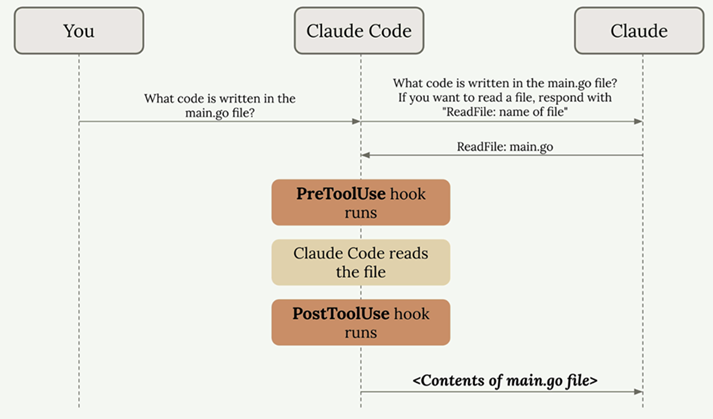

In [23]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/claude_code_hooks.png', embed=True))

**Hooks are defined in Claude settings files.** You can add them to:
- Global - ~/.claude/settings.json (affects all projects)
- Project - .claude/settings.json (shared with team)
- Project (not committed) - .claude/settings.local.json (personal settings)<br><br>

- You can write hooks by hand in these files or use the /hooks command inside Claude Code.
    - "matcher" matches the tool name .. and if read tool is being requested by claude then it executes the commands mentioned.
    - Similarly multiple tools can be matched also - as done in post tool use section below. 

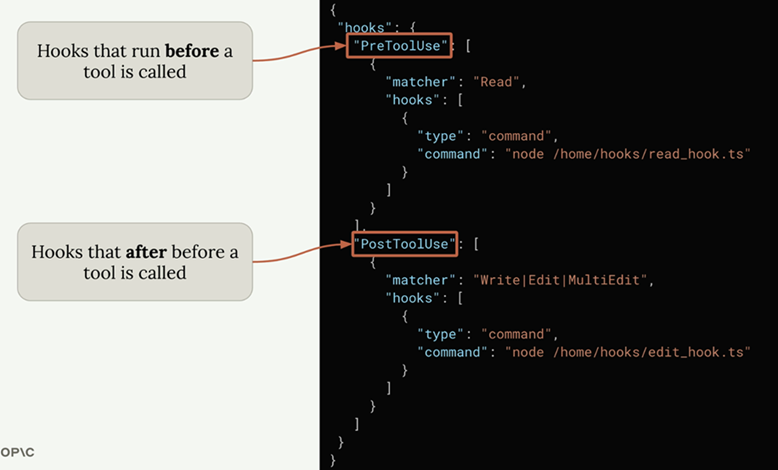

In [24]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/claude_code_hooks_v2.png', embed=True))

### Example - using hook to prevent claude from ever reading .env file
- Even if we add instruction in CLAUDE.md - claude can accidently read .env file - and our secrets can get exposed.
- To prevent this - we can use hooks -- pre tool call hook -- where - if a read file is being done on .env then we block that tool call from happening. <br><br>
- **To get all tool names** - built in tools as well as tools added via MCP servers - just open claude code in IDE -- and type prompt : "List out the names of all the tools you have access to, bullet point list"
- **Identify the tools** that can be used to read contents of a file - Read and Grep
- **Go to .claude/settings.local.json** -- add the following pre tool call hook check -- so in the below we are saying that if there is Read or Grep tool use - then run the command **`node $PWD/hooks/read_hook.js`** -- and inside read_hook.js we have the logic to extract data from tool call request from claude, check which file it is reading and handle it.
    ```json
        {
          "hooks": {
            "PreToolUse": [
              {
                "matcher": "Read|Grep",
                "hooks": [
                  { "type": "command", "command": "node $PWD/hooks/read_hook.js" }
                ]
              }
            ]
          }
        }
    ```
<br><br>
- When claude does a tool call - we will get tool call request in following format from claude : 
    ```json
    {
      "session_id": "2d6a1e4d-6...",
      "transcript_path": "/Users/sg/...",
      "hook_event_name": "PreToolUse",
      "tool_name": "Read",
      "tool_input": {
        "file_path": "/code/queries/.env"
      }
    }
    ```
- So we have the file **read_hook.js** as follows : 
    - Note that this script need not be javascript - it could be anything - even python.
    - When the pre tool call hook calls read_hook.js -- it passes the tool request json as command line argument to the script - so in the below - we extract json from the command line arg of the script -- and then extract the file name from the json under "file_path"
    - If file_path contains .env - then we throw an error with a message showing that it is not allowed -- else exit(0) to allow the tool use.

    ```js
        async function main() {
          const chunks = [];
          for await (const chunk of process.stdin) {
            chunks.push(chunk);
          }

          const toolArgs = JSON.parse(Buffer.concat(chunks).toString());

          // readPath is the path to the file that Claude is trying to read
          const readPath =
            toolArgs.tool_input?.file_path || toolArgs.tool_input?.path || "";

          // ensure Claude isn't trying to read the .env file
          if (readPath.includes('.env')) {
            console.error("You cannot read the .env file")
            process.exit(2);
          }
        }
        
        main();
    ```

### Key things to consider around security - when using hooks

- **Security Best Practices:**
    1. **Validate and Sanitize:** Never trust input data blindly.
    2. **Quote Variables:** Use `"$VAR"` instead of `$VAR` in shell scripts.
    3. **Block Path Traversal:** Check for `..` in file paths.
    4. **Absolute Paths:** Always specify full paths for scripts to prevent **path interception** and **binary planting** attacks.
    5.  **Skip Sensitive Files:** Explicitly avoid files like `.env`, `.git/`, and encryption keys.<br><br>

- **Handling Portability (`$PWD`):**
    - One of the recommendations is to use absolute paths (rather than relative paths) for scripts. This helps mitigate path interception and binary planting attacks.
    - Since absolute paths vary between machines, the `settings.example.json` in the examples shared above contains a **`$PWD`** placeholder.
    - Running `npm run setup` triggers an `init-claude.js` script that replaces `$PWD` with actual local absolute path.
    - This generates a `settings.local.json` file, allowing team members to share hook configurations without breaking path references.
    - So such kind of forced parsing should be implemented in projects - to ensure that the solution can run with absolute path. 

### Useful hook 1 : if updating a function definition - then update its call statements also.
- If you ask claude to update a function definition - then it will just do that - and not make any change to the call statements - leading to incompatibility. 
- To overcome this - after write-tool call is complete --- then run a hook - which checks for any errors in the codebase -- similar to how VS code checks it when you update any funciton -- and then pass the errors to claude as hook output - claude will then be able to make corrections.<br><br>
- Following is the script that was used here - but it can be customized basis your use case - and it can even be written in python if needed. 
    ```ts
        import * as ts from "typescript";
        import * as path from "path";

        // Read stdin
        async function readInput() {
          const chunks = [];
          for await (const chunk of process.stdin) {
            chunks.push(chunk);
          }
          return JSON.parse(Buffer.concat(chunks).toString());
        }

        function runTypeCheck(configPath) {
          // Parse the tsconfig.json file
          const configFile = ts.readConfigFile(configPath, ts.sys.readFile);
          if (configFile.error) {
            console.error(
              ts.formatDiagnostic(configFile.error, {
                getCanonicalFileName: (x) => x,
                getCurrentDirectory: ts.sys.getCurrentDirectory,
                getNewLine: () => ts.sys.newLine,
              })
            );
            return;
          }

          // Parse the configuration
          const parseConfigHost = {
            fileExists: ts.sys.fileExists,
            readFile: ts.sys.readFile,
            readDirectory: ts.sys.readDirectory,
            getCurrentDirectory: ts.sys.getCurrentDirectory,
            onUnrecoverableConfigFileDiagnostic: () => {},
          };      

          const parsed = ts.parseJsonConfigFileContent(
            configFile.config,
            parseConfigHost,
            path.dirname(configPath)
          );

          // Override to ensure no emit
          const compilerOptions = {
            ...parsed.options,
            noEmit: true,
          };

          // Create the program
          const program = ts.createProgram(parsed.fileNames, compilerOptions);

          // Get all diagnostics
          const allDiagnostics = ts.getPreEmitDiagnostics(program);

          // Format and display diagnostics
          if (allDiagnostics.length > 0) {
            const formatHost = {
              getCanonicalFileName: (path) => path,
              getCurrentDirectory: ts.sys.getCurrentDirectory,
              getNewLine: () => ts.sys.newLine,
            };

            const formattedDiagnostics = ts.formatDiagnostics(
              allDiagnostics,
              formatHost
            );

            return formattedDiagnostics; // Type check failed
          }

          return null; // Type check passed
        }

        async function main() {
          const input = await readInput();
          const file = input.tool_response?.filePath || input.tool_input?.file_path;

          // Only check TypeScript files
          if (!file || !/\.(ts|tsx)$/.test(file)) {
            process.exit(0);
          }

          const typeChecks = runTypeCheck("./tsconfig.json");
          if (typeChecks) {
            console.error(typeChecks);
            process.exit(2);
          }
        }

        main();
    ```

### Useful hook 2 : if updating any file under utils then start another claude code session and check if a similar function already exists - and use of modify that - instead of creating a new one which will duplicate code.
- If you ask claude to add a query - or function - it will create new functions instead of reusing existing. 
- To overcome this - before any write, edit or multi-edit tool call is started -- to modify a file under utils .. or any other target folder  --- then run a hook - which :
    1. Runs a separate claude code session - using **claude code SDK**
    2. Asks claude code to check the files inside the querries or target directory and see if a similar function already exists
    3. If it exists then exit by giving this feedback to main claude code session - so that it can reuse that instead of creating a new now.<br><br>
- Following is the script that was used here - but it can be customized basis your use case - and it can even be written in python if needed. 
    ```ts
            import { query } from "@anthropic-ai/claude-code";
            import path from "path";

            const REVIEW_DIR = "src/queries";

            async function main() {
              // Read JSON input from stdin
              const input = await new Promise((resolve) => {
                let data = "";
                process.stdin.on("data", (chunk) => (data += chunk));
                process.stdin.on("end", () => resolve(data));
              });

              const hookData = JSON.parse(input);
              const toolInput = hookData.tool_input;

              // Check if this is a file modification in ./queries
              const filePath = toolInput.file_path || toolInput.path;
              if (!filePath) {
                process.exit(0);
              }
              // Normalize paths for comparison
              const normalizedFilePath = path.resolve(filePath);
              const queriesDir = path.resolve(process.cwd(), REVIEW_DIR);

              // Check if file is within queries directory (handles subdirectories too)
              if (!normalizedFilePath.startsWith(queriesDir + path.sep)) {
                process.exit(0);
              }

              // Prepare prompt for analysis
              const newContent = toolInput.content || toolInput.contents;
              const prompt = `You are reviewing a proposed change to a database query file.
            Your task is to analyze if the new or modified query functions could be
            accomplished by reusing or slightly modifying existing query functions.

            Within reason, we want to prevent duplicate queries from being added into the
            File: ${filePath}
            New content:
            <new_content>
            ${newContent}
            </new_content>

            Please research and analyze the existing queries in the ./queries directory and:
            1. Identify any new query functions being added in this change
            2. For each new query function, determine if it could be accomplished by:
              - Using an existing query function as-is
              - Slightly modifying an existing query function, perhaps by adding additional
                arguments or expanding a select statement

            If yes, provide specific feedback on which existing functions could be used.
            If no, just say "Changes look appropriate."`;

              // Using claude code sdk to launch it programatically
              const messages = [];
              for await (const message of query({
                prompt,
                abortController: new AbortController(),
              })) {
                messages.push(message);
              }

              // Extract the analysis result
              const resultMessage = messages.find((m) => m.type === "result");
              if (!resultMessage || resultMessage.subtype !== "success") {
                process.exit(0);
              }

              // If changes are appropriate, allow them
              if (resultMessage.result.includes("Changes look appropriate")) {
                process.exit(0);
              }

              // Otherwise, block with feedback
              console.error(`Query duplication detected:\n\n${resultMessage.result}`);
              process.exit(2);
            }

            main().catch((err) => {
              console.error(`Hook error: ${err.message}`);
              process.exit(1);
            });

            main();
    ```

### Additional Hook types that can be used
* There are many other hooks in claude code : 
    * `Notification`: Runs when Claude needs permissions or is idle for 60s.
    * `Stop` / `SubagentStop`: Runs when Claude or a subagent finishes a task.
    * `PreCompact`: Runs before context window compression.
    * `UserPromptSubmit`: Runs after you hit enter, before Claude processes it.
    * `SessionStart` / `SessionEnd`: Triggers at the beginning or end of a session.<br><br>

* **The "Confusing Part":** The data format sent to `stdin` changes depending on the hook type and the specific tool being used.

**1. PostToolUse (TodoWrite):**
```json
{
  "session_id": "9ecf22fa-edf8-4332-ae85-b6d5456eda64",
  "transcript_path": "<path_to_transcript>",
  "hook_event_name": "PostToolUse",
  "tool_name": "TodoWrite",
  "tool_input": {
    "todos": [{ "content": "write a readme", "status": "pending", "id": "1" }]
  },
  "tool_response": {
    "oldTodos": [],
    "newTodos": [{ "content": "write a readme", "status": "pending", "id": "1" }]
  }
}
```

**2. Stop Hook:**
```json
{
  "session_id": "af9f50b6-f042-4773-b3e2-c3a4814765ce",
  "transcript_path": "<path_to_transcript>",
  "hook_event_name": "Stop",
  "stop_hook_active": false
}
```

---

#### **The Helper Hook (Debugging)**

To see exactly what data Claude is sending to your script, add this to your `claude.json`:

```json
// Add this for the hook that you want to use -- use PreCompact, UserPromptSubmit or anything else needed
"Stop": [
  {
    "matcher": "*",
    "hooks": [
      {
        "type": "command",
        "command": "jq . > post-log.json"
      }
    ]
  }
]
```

**Explanation:**
* Since each hook has different data structure - the above takes the "hidden" JSON data that Claude sends to the hook and saves it into a file called `post-log.json`. You can then open that file to see the exact field names and values - and then use that to write the logic that you want in the hook - by extracting information from the json.


### 40.1.13  i) Claude Code SDK
- As seen in Useful hook 2 -- Claude Code SDK allows us to execute claude code programatically - via CLI, typescript library or python library
- **`npm install @anthropic-ai/claude-agent-sdk`** to install the sdk<br><br>
- Example implementation -- sdk.ts: 
    ```ts
        import { query } from "@anthropic-ai/claude-code";

        const prompt = "Add a description to the package.json file";

        for await (const message of query({
          prompt,
          options: {
            allowedTools: ["Edit", "Glob"],
          },
        })) {
          console.log(JSON.stringify(message, null, 2));
        }
    ```
- Next run **`npm run sdk`** --- It will run the claude code using the sdk and it will fire the prompt above. 
- **Note :** The SDK can only use the tools that we specify in **"allowedTools"** list --- this behavious is similar to claude code in gitHub<br><br>
- **This can be used to create workflows with claude code as the orchestrator - for agentic workflows.**


## 40.1.14) Workflows & Agents

### 40.1.14  a) Workflows and Agents - Overview
- **Workflows :**
    - If we know the exact set of tasks and sequence to be done then it is called a workflow
    - i.e. **Worklows have predetermined steps**
    - There are several workflows that engineers have already identified
        1. Evaluator-Optimizer workflow
        2. Parallelization workflows
        3. Chaining workflows
        4. Routing workflows<br><br>
- **Agents :**
    - If the exact details of tasks that are needed to be solved is not known then agent is used.<br><br>
- **Agents vs Workflows :**
    - The user does not care if the task is getting done by workflow or agent
    - Agents introduce variability in the system -- so use them only if problem is truly complex and cant have a predefined set of steps
    - **Where steps are easy -- always prefer workflows**


### 40.1.14  b) Evaluator-Optimizer Workflow
- **Producer:** Takes input and creates output
- **Grader:** Evaluates the output against some criteria
- **Feedback loop:** If the grader doesn't accept the output, feedback goes back to the producer for improvement
- **Iteration:** The cycle repeats until the grader accepts the output<br><br>
- The workflow is shown in the diagram below - on the right. There is also an example in the left : 
    - A 2D image is fed to claude -- and it is asked to describe it
    - In a new session - based on the description - the image is fed and it is asked to generate 3D model object
    - Next - the 3D model object is taken - and a person manually - or using software if possible - creates the rendering
    - Then Claude is asked to compare rendering against the image - and asked to fix any gaps <br><br>
- Now the basic idea is the same -- but the workflow can be fully automated - or it can also have manual steps in between - depending on the integrations available with claude.


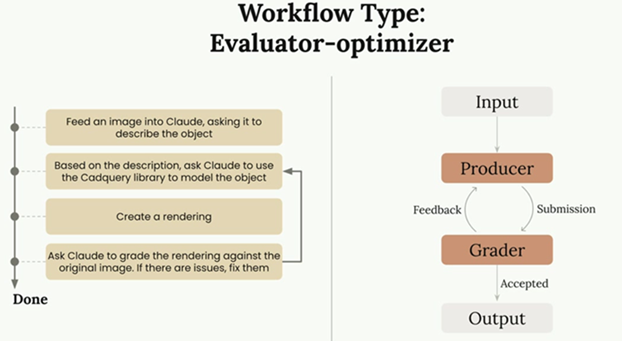

In [13]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/workflow_1.png', embed=True))

### 40.1.14  c) Parallelization Workflows
- Split a single task into multiple sub-tasks - Break down the complex decision into focused, specialized evaluations
- Run the sub-tasks in parallel - Execute all evaluations simultaneously for faster processing
- Aggregate the results together - Combine the specialized analyses into a final decision
- The parallelized sub-tasks don't need to be identical - Each can have a specialized prompt, set of tools, or evaluation criteria<br><br>
- **Advantages :**
    - Focused attention
    - Easier optimization
    - Better scalability
    - Improved reliability<br><br>
- The workflow is shown in the diagram below - on the right. There is also an example in the left : 
    - Lets say we want to analyze the image and determine which material it should be made of - metal, wood, polymer - etc
    - Now each material requires its own independent detail analysis - and doing all of that in one prompt would be bad - as claude will get confused - and plus there is no dependency on one material on other
    - So its best to parallelize the analysis part per material .. and then in the end - the analysis result can be put into a single chat to summarize and select the best one.


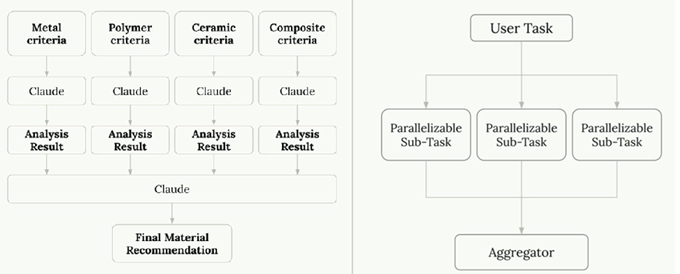

In [21]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/workflow_2.png', embed=True))

### 40.1.14  d) Chaining Workflows
- Split a large task into smaller non-parallelizable subtasks
- Optionally, do non-LLM processing in between each task
- Useful for keeping Claude focused on one aspect of the overall task criteria<br><br>
- **Why not a single big prompt :**
    - The key benefit is focus - when you give Claude one specific task at a time, it can concentrate on doing that task well rather than juggling multiple requirements simultaneously.<br><br>
    - **Example : Long promt problem :**
        - **Problem:** You ask claude to write an article -- and you notice that the results have emojis etc - so you keep adding multiple constraints in your single prompt (no AI mention, no emojis, professional tone, avoid clichés) --> model still violates some rules.
        - **Solution (2-step chaining):**
        ```text
        Step 1: Ask claude to generate content --> accept imperfect output
        Step 2: Ask claude to revise the content with targeted instructions:
                - Remove AI mentions
                - Remove emojis
                - Fix unprofessional / clichéd language
        ```
        - **Why it works:** Separates **generation** from **focused constraint fixing**, improving rule adherence.<br><br>
- The workflow is shown in the diagram below - on the right. There is also an example in the left.
    - The example is for you to create a video to post on social media on a topic


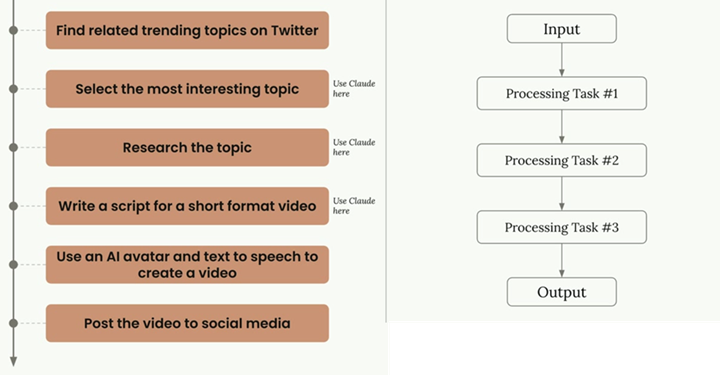

In [20]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/workflow_3.png', embed=True))

### 40.1.14  e) Routing Workflows
- Route user input to **one specialized pipeline** instead of a generic prompt
- First classify the request, then process using a category-specific prompt
- Useful when different inputs need **different handling styles** (not one-size-fits-all)<br><br>

- **Why not a single big prompt :**

  - Different types of inputs require different styles → one prompt cannot optimize for all cases<br><br>

  - **Example : Content generation (video scripts) :**

    - **Problem:** A user want to generate script for a topic -- but topic can be very different like *"programming"* or *"surfing"* → both need very different outputs

      - Programming → educational : This needs clear explanations - no need for emotions, excitement
      - Surfing → entertainment : This needs emotions, excitement, visuals<br>
        → So using a common prompt to generate content for very different genre will result in bad outcome.
    - **Solution (Routing):**

    ```text
    Step 1: Categorize input
            Input: "Python functions"
            → Category: Educational

    Step 2: Route to specialized prompt
            → Use educational prompt to generate script
    ```

    - **Why it works:** Uses **classification → specialization**, allowing each pipeline to be optimized for its specific use case<br><br>

- **Workflow architecture:**

```text
User Input
   ↓
Router (LLM categorization)
   ↓
One selected pipeline (not all)
   ↓
Specialized prompt / workflow
```

- The workflow ensures input is handled by **only one optimized path**, improving output quality and relevance


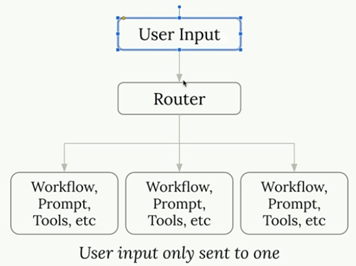

In [19]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/workflow_4.png', embed=True))

### 40.1.14  f) Agents
- Agents are effective when we dont know what steps are really required to solve a problem , or achieve an objective.
- In this case - we give Claude a task .. and a set of tools. And we rely upon claude to create a plan to complete the task using the given tools.
- This way once you build an agent - the agent can then do a wide variety of different tasks<br><br>
- The tools that you provide to an agent should be abstract - and should be able to help the agent in variety of activities - It should not be specific
    - Example : Claude Code has access to generic, flexible tools like:
        - bash - Run any command
        - read - Read any file
        - write - Create any file
        - edit - Modify files
        - glob - Find files
        - grep - Search file contents
    - And using the above - claude code can use these tools - combine them in different ways and achieve complex activities that we give it - like refactoring a codebase<br><br>
    - Similarly - for a social media video content generation platform agent - we will need to give the following tools to the agent. Note all of these are general purpose - they are not specific to anything : 
        - bash - Access to FFMPEG for video processing
        - generate_image - Create images from prompts
        - text_to_speech - Convert text to audio
        - post_media - Upload content to social platforms


## Environment Inspection
- Claude is an LLM - **it operates bindly.**<br><br>
- When we looked at computer use previously - i.e. when we gave a sandbox terminal access to claude for claude to be able to run code in it for any data analysis -- or any ppt creation -- it cannot see the output -- it can only see the code<br><br>
- So for better output - we have to give claude the ability to actually see the output - by rendering image of the website , ppt, document - or anything else -- and then claude can use image model to actually see the rendered output - and then take corrective actions as needed<br><br>
- Example : In the social media video generator tool -- after generating the video - we can have a system prompt -- which asks claude to use bash tool to run the video and take screenshot from every second and verify if the video looks ok.<br><br>
- We can also ask it to convert audio to text - along with timestamps .. and use it along with video images to ensure that the dialogs were placed correctly